# Final URA Model Training

This notebook trains the final selected model for the primary target:

- `target_next_URA`

It consumes the tuning results from `model_final_hyperparameter_tuning.ipynb`, selects the best validation candidate, trains it on train + validation, evaluates once on test, and can optionally refit on all rows for production use.

## 1. Configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import inspect
import json
import time
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
MODEL_DATA_PATH = Path("data/road_model_dataset_v2.parquet")
EVENT_HISTORY_PATH = Path("data/road_event_history_v2.parquet")
TUNING_DIR = Path("results/final_model_tuning")
COMPARISON_DIR = Path("results/final_model_comparison")
RESULT_DIR = Path("results/final_model_training")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "target_next_URA"
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

# If the selected model is RF and full training is too heavy, set this to a row limit.
RF_FINAL_TRAIN_LIMIT = 600_000
TRAIN_PRODUCTION_MODEL_ON_ALL_ROWS = False

print(f"Final training outputs will be written to: {RESULT_DIR.resolve()}")

Final training outputs will be written to: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_training


## 2. Load Selected Hyperparameters

In [2]:
def load_best_candidate(tuning_dir: Path) -> pd.Series:
    candidates = []
    for path in [
        tuning_dir / "all_ura_validation_tuning_results.csv",
        tuning_dir / "hgb_ura_validation_tuning.csv",
        tuning_dir / "rf_ura_validation_tuning_sampled.csv",
        tuning_dir / "hgb_ura_delta_validation_tuning.csv",
        tuning_dir / "hgb_ura_delta_focused_tuning.csv",
        tuning_dir / "hgb_ura_delta_all_tuning.csv",
    ]:
        if path.exists():
            candidate = pd.read_csv(path)
            if "target_type" not in candidate.columns:
                candidate["target_type"] = "direct"
            candidates.append(candidate)
    if not candidates:
        raise FileNotFoundError(
            "No tuning result CSVs found. Run model_final_hyperparameter_tuning.ipynb first."
        )
    tuning = pd.concat(candidates, ignore_index=True).drop_duplicates()
    tuning = tuning.loc[tuning["target"].eq(TARGET)].copy()
    if tuning.empty:
        raise ValueError(f"No tuning rows found for {TARGET}.")
    display(tuning.sort_values("rmse"))
    return tuning.sort_values("rmse").iloc[0]


best_candidate = load_best_candidate(TUNING_DIR)
MODEL_NAME = best_candidate["model"]
MODEL_PARAMS = json.loads(best_candidate["params"])
TARGET_TYPE = best_candidate.get("target_type", "direct")
CURRENT_TARGET_COL = "URA"
print(f"Selected model: {MODEL_NAME}")
print(f"Selected params: {MODEL_PARAMS}")
print(f"Selected target type: {TARGET_TYPE}")

,model,target,candidate,params,mae,rmse,r2,train_rows,evaluation_rows,fit_seconds,target_type
19,hist_gradient_boosting,target_next_URA,18.0,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l...",1.056438,1.645404,0.861152,2683410,574718,51.376046,delta_converted_to_actual
20,hist_gradient_boosting,target_next_URA,10.0,"{""learning_rate"": 0.1, ""max_iter"": 350, ""max_l...",1.062200,1.649290,0.860495,2683410,574718,46.152275,delta_converted_to_actual
21,hist_gradient_boosting,target_next_URA,19.0,"{""learning_rate"": 0.06, ""max_iter"": 650, ""max_...",1.069874,1.660783,0.858544,2683410,574718,72.813696,delta_converted_to_actual
22,hist_gradient_boosting,target_next_URA,17.0,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l...",1.068760,1.661052,0.858498,2683410,574718,49.772665,delta_converted_to_actual
23,hist_gradient_boosting,target_next_URA,8.0,"{""learning_rate"": 0.08, ""max_iter"": 350, ""max_...",1.073049,1.662577,0.858238,2683410,574718,48.879364,delta_converted_to_actual
24,hist_gradient_boosting,target_next_URA,9.0,"{""learning_rate"": 0.1, ""max_iter"": 350, ""max_l...",1.075491,1.666525,0.857564,2683410,574718,44.827987,delta_converted_to_actual
25,hist_gradient_boosting,target_next_URA,20.0,"{""learning_rate"": 0.12, ""max_iter"": 300, ""max_...",1.075782,1.668061,0.857301,2683410,574718,39.134411,delta_converted_to_actual
26,hist_gradient_boosting,target_next_URA,7.0,"{""learning_rate"": 0.08, ""max_iter"": 350, ""max_...",1.086370,1.679845,0.855278,2683410,574718,45.145880,delta_converted_to_actual
27,hist_gradient_boosting,target_next_URA,3.0,"{""learning_rate"": 0.08, ""max_iter"": 500, ""max_...",1.089145,1.683035,0.854728,2683410,574718,53.646091,delta_converted_to_actual
28,hist_gradient_boosting,target_next_URA,5.0,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l...",1.089515,1.684655,0.854448,2683410,574718,44.840221,delta_converted_to_actual


Selected model: hist_gradient_boosting
Selected params: {'learning_rate': 0.1, 'max_iter': 400, 'max_leaf_nodes': 127, 'min_samples_leaf': 150, 'l2_regularization': 0.1}
Selected target type: delta_converted_to_actual


## 3. Load Data and Rebuild Features

In [3]:
MODEL_COLUMNS = [
    "Segment_ID", "Lifecycle_ID", "event_date", "ELY",
    "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "IRI", "URA", "prev_IRI", "prev_URA", "Delta_t_years",
    "Pavement_Age_years", "Minor_TP_Count", "tp_count_interval",
    "target_next_URA", "target_next_IRI", "target_horizon_days", "target_horizon_years",
]

df = pd.read_parquet(MODEL_DATA_PATH, columns=MODEL_COLUMNS)
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["observed_lifecycle_age_years"] = pd.to_numeric(df["Pavement_Age_years"], errors="coerce")

SURFACE_TYPE_MAP = {"ab": "AB", "abk": "AB", "abs": "AB", "ea": "AB", "pab-v": "PAB", "pab-b": "PAB", "pab-o": "PAB", "sma": "SMA"}
MATERIAL_TYPE_MAP = {"lta": "new", "mp": "new", "mpkj": "new", "art": "new", "mpk": "new", "rem": "recycled", "urem": "recycled", "remo": "recycled", "rem+": "recycled"}

def normalize_token(value):
    if pd.isna(value):
        return None
    token = str(value).strip().lower()
    return token if token else None

def classify_surface(value):
    token = normalize_token(value)
    return "unknown" if token is None else SURFACE_TYPE_MAP.get(token, "other")

def classify_material(value):
    token = normalize_token(value)
    return "unknown" if token is None else MATERIAL_TYPE_MAP.get(token, "other")

def add_current_material_state(model_df, event_history_path):
    cols = ["event_type", "Segment_ID", "event_date", "Tp_pinta", "Tp_tyomen", "tp_idx"]
    try:
        tp = pd.read_parquet(event_history_path, columns=cols, filters=[("event_type", "==", "TP")])
    except (TypeError, ValueError):
        events = pd.read_parquet(event_history_path, columns=cols)
        tp = events.loc[events["event_type"].eq("TP")].copy()
    tp = tp.dropna(subset=["Segment_ID", "event_date"]).copy()
    tp["event_date"] = pd.to_datetime(tp["event_date"], errors="coerce")
    tp = tp.dropna(subset=["event_date"])
    tp["surface_type_current"] = tp["Tp_pinta"].map(classify_surface)
    tp["material_type_current"] = tp["Tp_tyomen"].map(classify_material)
    tp["tp_idx"] = pd.to_numeric(tp["tp_idx"], errors="coerce")

    left = model_df.reset_index(names="_row_id").sort_values(["event_date", "Segment_ID"], kind="mergesort")
    right = (
        tp[["Segment_ID", "event_date", "tp_idx", "surface_type_current", "material_type_current"]]
        .sort_values(["event_date", "Segment_ID", "tp_idx"], kind="mergesort")
        .rename(columns={"event_date": "latest_material_event_date"})
    )
    merged = pd.merge_asof(
        left, right,
        left_on="event_date", right_on="latest_material_event_date",
        by="Segment_ID", direction="backward", allow_exact_matches=True,
    )
    merged["surface_type_current"] = merged["surface_type_current"].fillna("unknown")
    merged["material_type_current"] = merged["material_type_current"].fillna("unknown")
    merged["years_since_material_update"] = (merged["event_date"] - merged["latest_material_event_date"]).dt.days / 365.25
    return merged.sort_values("_row_id", kind="mergesort").drop(columns=["_row_id", "tp_idx"]).reset_index(drop=True)

df = add_current_material_state(df, EVENT_HISTORY_PATH)
print(f"Rows: {len(df):,}; segments: {df['Segment_ID'].nunique():,}")

Rows: 3,833,323; segments: 996,476


## 4. Split and Preprocessing

In [4]:
def make_ely_segment_split(frame, train_frac, val_frac, test_frac, random_state):
    rng = np.random.default_rng(random_state)
    segment_split = {}
    segment_ely = frame[["Segment_ID", "ELY"]].drop_duplicates()
    for ely, group in segment_ely.groupby("ELY", sort=True):
        segments = group["Segment_ID"].to_numpy(copy=True)
        rng.shuffle(segments)
        n = len(segments)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_train = min(max(n_train, 1), n - 2)
        n_val = min(max(n_val, 1), n - n_train - 1)
        for seg in segments[:n_train]:
            segment_split[seg] = "train"
        for seg in segments[n_train:n_train + n_val]:
            segment_split[seg] = "validation"
        for seg in segments[n_train + n_val:]:
            segment_split[seg] = "test"
    return frame["Segment_ID"].map(segment_split).astype("category")

df["split"] = make_ely_segment_split(df, TRAIN_FRACTION, VALIDATION_FRACTION, TEST_FRACTION, RANDOM_STATE)
assert df[["Segment_ID", "split"]].drop_duplicates().groupby("Segment_ID")["split"].nunique().max() == 1

FEATURES = [
    "URA", "IRI", "target_horizon_years",
    "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "prev_URA", "prev_IRI", "Delta_t_years",
    "observed_lifecycle_age_years", "Minor_TP_Count",
    "tp_count_interval", "surface_type_current", "material_type_current", "years_since_material_update",
]
CATEGORICAL_FEATURES = {"Toim_lk", "surface_type_current", "material_type_current"}
NUMERIC_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

def make_one_hot_encoder():
    params = {"handle_unknown": "ignore"}
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)

def build_preprocessor():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", make_one_hot_encoder()),
        ]), [c for c in FEATURES if c in CATEGORICAL_FEATURES]),
    ], remainder="drop", verbose_feature_names_out=True)

train_val_frame = df.loc[df["split"].isin(["train", "validation"])].copy()
test_frame = df.loc[df["split"].eq("test")].copy()
display(df["split"].value_counts().to_frame("rows"))

,rows
split,
train,2683410
test,575195
validation,574718


## 5. Train Selected Model and Evaluate Test Set

In [5]:
def metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }

def sample_frame(frame, limit):
    if limit is None or len(frame) <= limit:
        return frame
    return frame.sample(limit, random_state=RANDOM_STATE)

def make_estimator(model_name, params):
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            loss="squared_error",
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=25,
            random_state=RANDOM_STATE,
            **params,
        )
    if model_name == "random_forest":
        return RandomForestRegressor(
            n_jobs=-1,
            random_state=RANDOM_STATE,
            bootstrap=True,
            **params,
        )
    raise ValueError(f"Unknown model: {model_name}")

if TARGET_TYPE == "direct":
    TRAIN_TARGET = TARGET
    train_val_model_frame = train_val_frame
    test_pred_transform = lambda frame, pred: pred
elif TARGET_TYPE == "delta_converted_to_actual":
    TRAIN_TARGET = f"delta_{TARGET}"
    train_val_model_frame = train_val_frame.copy()
    train_val_model_frame[TRAIN_TARGET] = train_val_model_frame[TARGET] - train_val_model_frame[CURRENT_TARGET_COL]
    test_pred_transform = lambda frame, pred: frame[CURRENT_TARGET_COL].to_numpy() + pred
else:
    raise ValueError(f"Unsupported target type: {TARGET_TYPE}")

train_limit = RF_FINAL_TRAIN_LIMIT if MODEL_NAME == "random_forest" else None
fit_frame = sample_frame(train_val_model_frame, train_limit)
print(f"Training {MODEL_NAME} on {len(fit_frame):,} rows with target_type={TARGET_TYPE}")

pipeline = Pipeline([
    ("preprocess", build_preprocessor()),
    ("model", make_estimator(MODEL_NAME, MODEL_PARAMS)),
])
t0 = time.time()
pipeline.fit(fit_frame[FEATURES], fit_frame[TRAIN_TARGET])
fit_seconds = time.time() - t0

raw_test_pred = pipeline.predict(test_frame[FEATURES])
test_pred = test_pred_transform(test_frame, raw_test_pred)
test_metrics = metrics(test_frame[TARGET], test_pred)
result = {
    "model": MODEL_NAME,
    "target": TARGET,
    "target_type": TARGET_TYPE,
    "train_target": TRAIN_TARGET,
    "train_rows": len(fit_frame),
    "test_rows": len(test_frame),
    "fit_seconds": fit_seconds,
    "params": json.dumps(MODEL_PARAMS),
    **test_metrics,
}
display(pd.DataFrame([result]))

pd.DataFrame([result]).to_csv(RESULT_DIR / "final_ura_model_test_result.csv", index=False)
predictions = test_frame[["Segment_ID", "ELY", "event_date", "target_horizon_days", TARGET, "URA", "IRI"]].copy()
predictions["raw_model_prediction"] = raw_test_pred
predictions["prediction"] = test_pred
predictions.to_parquet(RESULT_DIR / "final_ura_model_test_predictions.parquet", index=False)
joblib.dump(pipeline, RESULT_DIR / "final_ura_model.joblib")
with open(RESULT_DIR / "final_ura_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": MODEL_NAME,
        "target": TARGET,
        "target_type": TARGET_TYPE,
        "train_target": TRAIN_TARGET,
        "current_target_col": CURRENT_TARGET_COL,
        "features": FEATURES,
        "params": MODEL_PARAMS,
        "random_state": RANDOM_STATE,
    }, f, indent=2)
print(f"Saved model and outputs to {RESULT_DIR.resolve()}")

Training hist_gradient_boosting on 3,258,128 rows with target_type=delta_converted_to_actual


,model,target,target_type,train_target,train_rows,test_rows,fit_seconds,params,mae,rmse,r2
0,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,delta_target_next_URA,3258128,575195,72.19424,"{""learning_rate"": 0.1, ""max_iter"": 400, ""max_l...",1.057844,1.643727,0.861921


Saved model and outputs to C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_training


## 6. Final Model Report Tables

In [6]:
HORIZON_WINDOWS = {"1y": (274, 457), "2y": (639, 822), "3y": (1004, 1187), "4y": (1370, 1553)}

report_predictions = predictions.copy()
report_predictions["residual"] = report_predictions[TARGET] - report_predictions["prediction"]
report_predictions["abs_error"] = report_predictions["residual"].abs()
report_predictions["horizon_window"] = "outside_windows"
for name, (lo, hi) in HORIZON_WINDOWS.items():
    mask = report_predictions["target_horizon_days"].between(lo, hi, inclusive="both")
    report_predictions.loc[mask, "horizon_window"] = name

breakdown_rows = []
for group_type, col in [("overall", None), ("horizon_window", "horizon_window"), ("ELY", "ELY")]:
    groups = [("overall", report_predictions)] if col is None else report_predictions.groupby(col, sort=True)
    for group_value, sub in groups:
        if group_value == "outside_windows":
            continue
        breakdown_rows.append({
            "model": MODEL_NAME,
            "target": TARGET,
            "target_type": TARGET_TYPE,
            "group_type": group_type,
            "group": group_value,
            "evaluation_rows": len(sub),
            **metrics(sub[TARGET], sub["prediction"]),
        })

breakdown_df = pd.DataFrame(breakdown_rows).sort_values(["group_type", "group", "rmse"])
display(breakdown_df)
breakdown_df.to_csv(RESULT_DIR / "final_ura_model_test_breakdowns.csv", index=False)
report_predictions.to_parquet(RESULT_DIR / "final_ura_model_test_predictions_with_residuals.parquet", index=False)

comparison_tables = []
comparison_path = COMPARISON_DIR / "test_results_overall.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    comparison = comparison.loc[comparison["target"].eq(TARGET)].copy()
    comparison["source"] = "final_model_comparison"
    comparison_tables.append(comparison)

direct_delta_path = COMPARISON_DIR / "direct_vs_delta_test_results.csv"
if direct_delta_path.exists():
    direct_delta = pd.read_csv(direct_delta_path)
    direct_delta = direct_delta.loc[direct_delta["target"].eq(TARGET)].copy()
    direct_delta["source"] = "direct_vs_delta_comparison"
    comparison_tables.append(direct_delta)

final_result = pd.DataFrame([{**result, "source": "final_selected_model", "feature_mixture": "current_static_lag_lifecycle_material", "split": "test", "evaluation_rows": result["test_rows"]}])
comparison_tables.append(final_result)
comparison_df = pd.concat(comparison_tables, ignore_index=True, sort=False)
display(comparison_df.sort_values("rmse")[["source", "model", "target", "target_type", "feature_mixture", "train_rows", "evaluation_rows", "test_rows", "mae", "rmse", "r2"]])
comparison_df.to_csv(RESULT_DIR / "final_ura_model_comparison_table.csv", index=False)

,model,target,target_type,group_type,group,evaluation_rows,mae,rmse,r2
5,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Epo,61939,1.036249,1.521239,0.868457
6,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Kas,31743,0.977235,1.545083,0.882578
7,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Kes,33919,1.025959,1.535571,0.862417
8,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Lap,54470,1.324306,2.057712,0.805580
9,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Pir,45640,0.961278,1.446003,0.900064
10,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Pop,78330,1.196544,1.831790,0.816791
11,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Pos,85984,1.098334,1.721208,0.848728
12,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Uud,113991,0.916713,1.401476,0.899574
13,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,ELY,Var,69179,1.008883,1.646149,0.859651
1,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,horizon_window,1y,273751,0.817304,1.215362,0.920334


,source,model,target,target_type,feature_mixture,train_rows,evaluation_rows,test_rows,mae,rmse,r2
8,final_selected_model,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,current_static_lag_lifecycle_material,3258128,NaN,575195.0,1.057844,1.643727,0.861921
6,direct_vs_delta_comparison,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.144561,1.754246,0.842729
7,direct_vs_delta_comparison,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.150635,1.765230,0.840754
0,final_model_comparison,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.150635,1.765230,0.840754
1,final_model_comparison,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,300000,575195.0,NaN,1.141090,1.774198,0.839131
2,final_model_comparison,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,150000,575195.0,NaN,1.209294,1.841161,0.826759
3,final_model_comparison,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.286372,1.923522,0.810913
4,final_model_comparison,ridge,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.286372,1.923522,0.810913
5,final_model_comparison,persistence,target_next_URA,direct,persistence,3258128,575195.0,NaN,1.894494,2.645991,0.642197


## 7. Final Model Figures

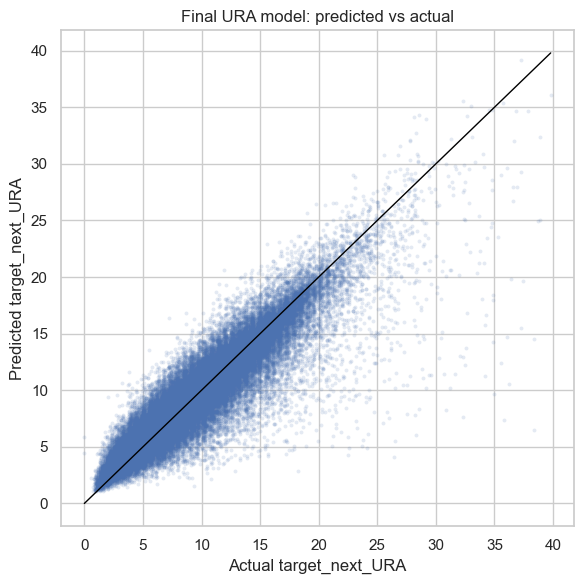

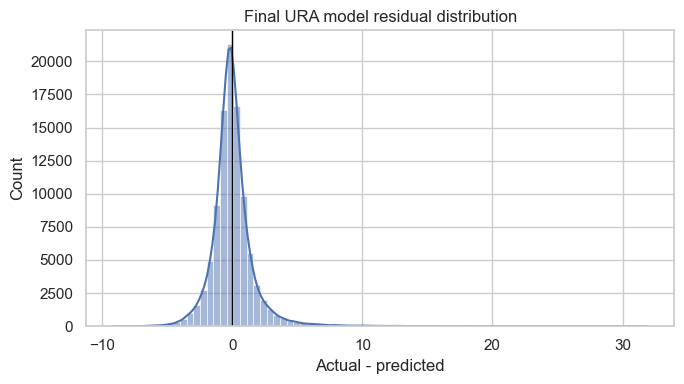

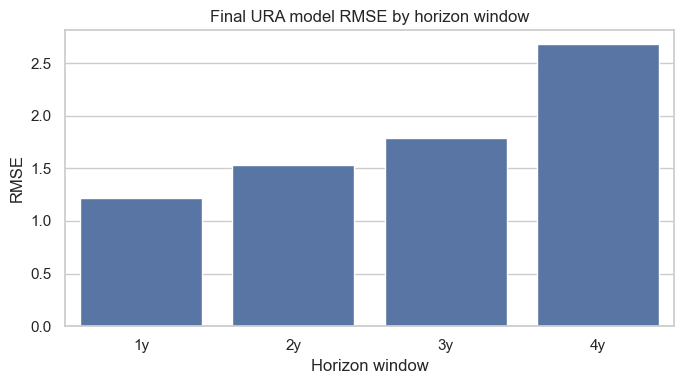

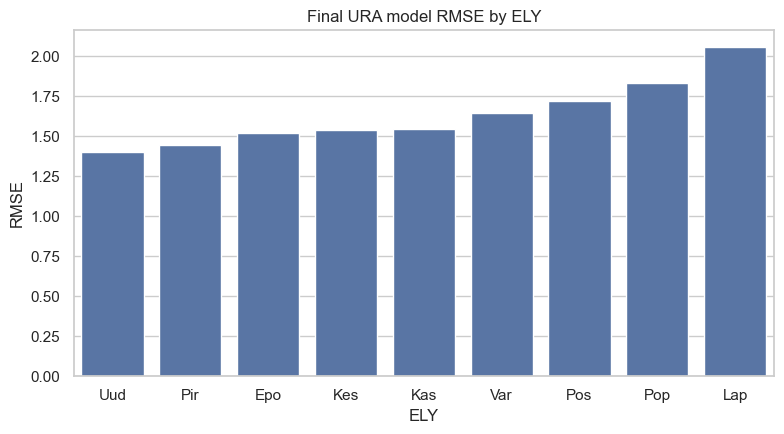

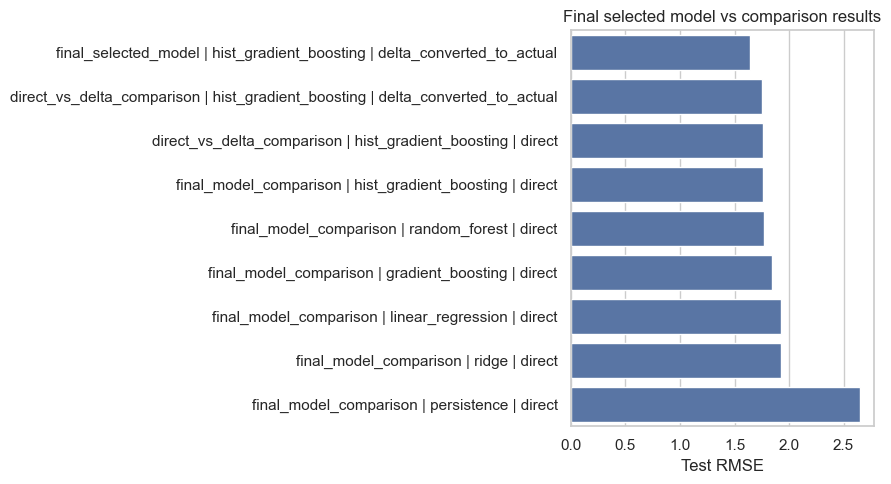

Figures saved to C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_training\figures


In [7]:
FIGURE_DIR = RESULT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plot_sample = report_predictions.sample(min(len(report_predictions), 100_000), random_state=RANDOM_STATE)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=plot_sample, x=TARGET, y="prediction", alpha=0.15, s=8, linewidth=0)
lims = [min(plot_sample[TARGET].min(), plot_sample["prediction"].min()), max(plot_sample[TARGET].max(), plot_sample["prediction"].max())]
plt.plot(lims, lims, color="black", linewidth=1)
plt.title("Final URA model: predicted vs actual")
plt.xlabel("Actual target_next_URA")
plt.ylabel("Predicted target_next_URA")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "predicted_vs_actual_ura.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(plot_sample["residual"], bins=80, kde=True)
plt.axvline(0, color="black", linewidth=1)
plt.title("Final URA model residual distribution")
plt.xlabel("Actual - predicted")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_distribution_ura.png", dpi=160)
plt.show()

horizon_plot = breakdown_df[breakdown_df["group_type"].eq("horizon_window")].copy()
plt.figure(figsize=(7, 4))
sns.barplot(data=horizon_plot, x="group", y="rmse", order=["1y", "2y", "3y", "4y"])
plt.title("Final URA model RMSE by horizon window")
plt.xlabel("Horizon window")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rmse_by_horizon_window_ura.png", dpi=160)
plt.show()

ely_plot = breakdown_df[breakdown_df["group_type"].eq("ELY")].sort_values("rmse")
plt.figure(figsize=(8, 4.5))
sns.barplot(data=ely_plot, x="group", y="rmse")
plt.title("Final URA model RMSE by ELY")
plt.xlabel("ELY")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rmse_by_ely_ura.png", dpi=160)
plt.show()

comparison_plot = comparison_df.loc[comparison_df["target"].eq(TARGET)].copy()
comparison_plot["label"] = comparison_plot["source"].fillna("comparison") + " | " + comparison_plot["model"].astype(str) + " | " + comparison_plot["target_type"].fillna("direct")
comparison_plot = comparison_plot.sort_values("rmse").head(10)
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_plot, y="label", x="rmse")
plt.title("Final selected model vs comparison results")
plt.xlabel("Test RMSE")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_model_vs_comparison_ura.png", dpi=160)
plt.show()

print(f"Figures saved to {FIGURE_DIR.resolve()}")

## 8. Optional Production Refit on All Rows

In [8]:
if TRAIN_PRODUCTION_MODEL_ON_ALL_ROWS:
    if MODEL_NAME == "random_forest" and RF_FINAL_TRAIN_LIMIT is not None:
        print("Skipping all-row production refit for RF because RF_FINAL_TRAIN_LIMIT is set.")
    else:
        print(f"Training production {MODEL_NAME} on all {len(df):,} rows")
        production_frame = df
        if TARGET_TYPE == "delta_converted_to_actual":
            production_frame = df.copy()
            production_frame[TRAIN_TARGET] = production_frame[TARGET] - production_frame[CURRENT_TARGET_COL]
        production_pipeline = Pipeline([
            ("preprocess", build_preprocessor()),
            ("model", make_estimator(MODEL_NAME, MODEL_PARAMS)),
        ])
        production_pipeline.fit(production_frame[FEATURES], production_frame[TRAIN_TARGET])
        joblib.dump(production_pipeline, RESULT_DIR / "production_ura_model_all_rows.joblib")
        print("Saved production all-row model.")
else:
    print("Production all-row refit disabled. Set TRAIN_PRODUCTION_MODEL_ON_ALL_ROWS=True to enable it.")

Production all-row refit disabled. Set TRAIN_PRODUCTION_MODEL_ON_ALL_ROWS=True to enable it.
